# Multi-Class Classification with Perceptron

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os

You can use the following perceptron training code from the lecture:

In [2]:
def train(positive_examples, negative_examples, num_iterations = 100):
    num_dims = positive_examples.shape[1]
    weights = np.zeros((num_dims,1)) # initialize weights
    
    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]
    
    report_frequency = 10
    
    for i in range(num_iterations):
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights)   
        if z < 0:
            weights = weights + pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0:
            weights = weights - neg.reshape(weights.shape)
            
        if i % report_frequency == 0:             
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)        
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights

In [3]:
def accuracy(weights, test_x, test_labels):
    res = np.dot(np.c_[test_x,np.ones(len(test_x))],weights)
    return (res.reshape(test_labels.shape)*test_labels>=0).sum()/float(len(test_labels))

# accuracy(wts, test_x, test_labels)

### Reading the Dataset

This code download the dataset from the repository on the internet. You can also manually copy the dataset from `/data` directory of AI Curriculum repo.

In [4]:
# !rm *.pkl
# https://github.com/mnielsen/neural-networks-and-deep-learning/blob/master/data/mnist.pkl.gz
# !gzip -d mnist.pkl.gz

import os
import requests

# 这里的 IP 和端口换成你 set_proxy.sh 里的内容,wsl需要将代理映射到主机ip的代理端口
proxy_url = "http://172.24.112.1:7897"

# 设置全局环境变量，注意键名区分大小写，建议都写上
os.environ['http_proxy'] = proxy_url
os.environ['https_proxy'] = proxy_url
os.environ['HTTP_PROXY'] = proxy_url
os.environ['HTTPS_PROXY'] = proxy_url

# 测试一下，由于设置了环境变量，这里的请求会自动走代理
try:
    response = requests.get("https://www.google.com", timeout=5)
    print("代理连接成功，状态码:", response.status_code)
except requests.exceptions.RequestException as e:
    print("请求失败:", e)
import sys
!{sys.executable} -m pip install git+https://github.com/nilp0inter/experta

# !rm -f *.pkl *.pkl.gz
# !wget https://raw.githubusercontent.com/mnielsen/neural-networks-and-deep-learning/master/data/mnist.pkl.gz
# !gzip -d mnist.pkl.gz

代理连接成功，状态码: 200
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Cloning https://github.com/nilp0inter/experta to /tmp/pip-req-build-bdrzsvu9
  Running command git clone --filter=blob:none --quiet https://github.com/nilp0inter/experta /tmp/pip-req-build-bdrzsvu9
  Resolved https://github.com/nilp0inter/experta to commit c6d5834b123861f5ae09e7d07027dc98bec58741
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
# with open('mnist.pkl', 'rb') as mnist_pickle:
#     MNIST = pickle.load(mnist_pickle)

with open('mnist.pkl', 'rb') as mnist_pickle:
    # 在这里加上 encoding='latin1'
    MNIST = pickle.load(mnist_pickle, encoding='latin1')

In [6]:
# 接着加上我们之前讨论过的格式化代码
if isinstance(MNIST, tuple):
    if len(MNIST) == 3:
        train_set, valid_set, test_set = MNIST
    elif len(MNIST) == 2:
        train_set, test_set = MNIST
        
    MNIST = {
        'Train': {'Features': train_set[0], 'Labels': train_set[1]},
        'Test': {'Features': test_set[0], 'Labels': test_set[1]}
    }

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01171875 0.0703125
 0.0703125  0.0703125  0.4921875  0.53125    0.68359375 0.1015625
 0.6484375  0.99609375 0.96484375 0.49609375 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.1171875  0.140625
 0.3671875  0.6015625 ]
5


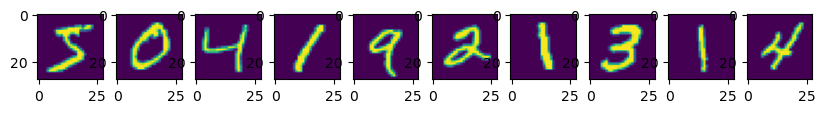

In [7]:
print(MNIST['Train']['Features'][0][130:180])
print(MNIST['Train']['Labels'][0])
features = MNIST['Train']['Features'].astype(np.float32) / 256.0
labels = MNIST['Train']['Labels']
fig = plt.figure(figsize=(10,5))
for i in range(10):
    ax = fig.add_subplot(1,10,i+1)
    plt.imshow(features[i].reshape(28,28))
plt.show()

Code to create *one-vs-other* dataset for two-digit classification. You need to modify this code to create *one-vs-all* dateset.

In [8]:
def set_mnist_pos_neg(positive_label, negative_label):
    positive_indices = [i for i, j in enumerate(MNIST['Train']['Labels']) 
                          if j == positive_label]
    negative_indices = [i for i, j in enumerate(MNIST['Train']['Labels']) 
                          if j == negative_label]

    positive_images = MNIST['Train']['Features'][positive_indices]
    negative_images = MNIST['Train']['Features'][negative_indices]

    return positive_images, negative_images

Now you need to:
1. Create 10 *one-vs-all* datasets for all digits
1. Train 10 perceptrons
1. Define `classify` function to perform digit classification
1. Measure the accuracy of classification and print *confusion matrix*
1. [Optional] Create improved `classify` function that performs the classification using one matrix multiplication.

In [18]:
import numpy as np
import random

# 1. 修改数据集切分函数，改为 One-vs-All 模式
def get_one_vs_all_data(target_digit, dataset_type='Train'):
    """
    为指定的数字生成“该数字 vs 其他所有数字”的二分类数据集。
    同时应用偏置技巧 (Bias Trick)，在特征末尾加上一列 1。
    """
    # 提取特征并归一化
    features = MNIST[dataset_type]['Features'].astype(np.float32) / 256.0
    labels = MNIST[dataset_type]['Labels']
    
    # 应用偏置技巧 (Bias Trick)
    features_with_bias = np.c_[features, np.ones(len(features))]
    
    # 找出正例（目标数字）和负例（其他所有数字）的索引
    positive_indices = [i for i, j in enumerate(labels) if j == target_digit]
    negative_indices = [i for i, j in enumerate(labels) if j != target_digit]
    
    positive_images = features_with_bias[positive_indices]
    negative_images = features_with_bias[negative_indices]
    
    return positive_images, negative_images

# 2. 训练 10 个感知机并将权重合并为一个矩阵 W
# 图片尺寸是 28x28 (784)，加上 1 个偏置项，总维度为 785
num_features = 28 * 28 + 1
# W 是最终的权重矩阵，形状为 (785, 10)，每一列代表一个数字的感知机权重
W = np.zeros((num_features, 10))

print("开始训练 10 个 One-vs-All 感知机...")
# 将迭代次数增加到 5000，以保证模型能看到足够的样本，提高准确率
iterations = 60000 

for digit in range(10):
    print(f"正在训练数字 {digit} 的专属分类器...")
    pos_train, neg_train = get_one_vs_all_data(digit, 'Train')
    
    # 调用上文提供的 train 函数进行训练
    w = train(pos_train, neg_train, num_iterations=iterations)
    
    # 将训练出来的结果(列向量)展平，存入权重矩阵 W 的对应列中
    W[:, digit] = w.flatten()

# 3. 定义 classify 函数，利用矩阵乘法实现高效的批量预测
def classify(features_matrix, weight_matrix):
    """
    利用权重矩阵对整个特征矩阵进行多分类。
    使用矩阵乘法计算得分，并返回得分最高的索引(即预测的数字)。
    """
    # 一次性计算出所有图片在 10 个感知机上的得分
    # scores 的形状将会是 (样本数量, 10)
    scores = np.dot(features_matrix, weight_matrix)
    
    # 在按行 (axis=1) 的方向上，找出得分最大值的索引
    predictions = np.argmax(scores, axis=1)
    
    return predictions

# 4. 评估测试集准确率并生成混淆矩阵
# 准备测试集特征并加上偏置列
test_features = MNIST['Test']['Features'].astype(np.float32) / 256.0
test_labels = MNIST['Test']['Labels']
test_features_bias = np.c_[test_features, np.ones(len(test_features))]

print("\n正在对测试集进行分类预测...")
test_predictions = classify(test_features_bias, W)

# 计算并打印准确率
accuracy = (test_predictions == test_labels).mean()
print(f"测试集整体准确率: {accuracy * 100:.2f}%\n")

# 生成混淆矩阵 (Confusion Matrix)
# 行代表真实的标签，列代表模型预测的标签
confusion_matrix = np.zeros((10, 10), dtype=int)
for true_label, pred_label in zip(test_labels, test_predictions):
    confusion_matrix[true_label, pred_label] += 1

print("混淆矩阵 (行 = 真实标签, 列 = 预测标签):")
print(confusion_matrix)

开始训练 10 个 One-vs-All 感知机...
正在训练数字 0 的专属分类器...
Iteration=0, pos correct=0.0, neg correct=1.0
Iteration=10, pos correct=0.0, neg correct=1.0
Iteration=20, pos correct=0.0, neg correct=1.0
Iteration=30, pos correct=0.0, neg correct=1.0
Iteration=40, pos correct=0.0, neg correct=1.0
Iteration=50, pos correct=0.0, neg correct=1.0
Iteration=60, pos correct=0.9817518248175182, neg correct=0.6815035058134374
Iteration=70, pos correct=0.985198702351987, neg correct=0.6553430371882488
Iteration=80, pos correct=0.98661800486618, neg correct=0.6556758675778823
Iteration=90, pos correct=0.9898621248986212, neg correct=0.5801677465163753
Iteration=100, pos correct=0.0, neg correct=1.0
Iteration=110, pos correct=0.0, neg correct=1.0
Iteration=120, pos correct=0.9937145174371452, neg correct=0.5033948699742611
Iteration=130, pos correct=0.0, neg correct=1.0
Iteration=140, pos correct=0.0, neg correct=1.0
Iteration=150, pos correct=0.9951338199513382, neg correct=0.5017529067187362
Iteration=160, pos 

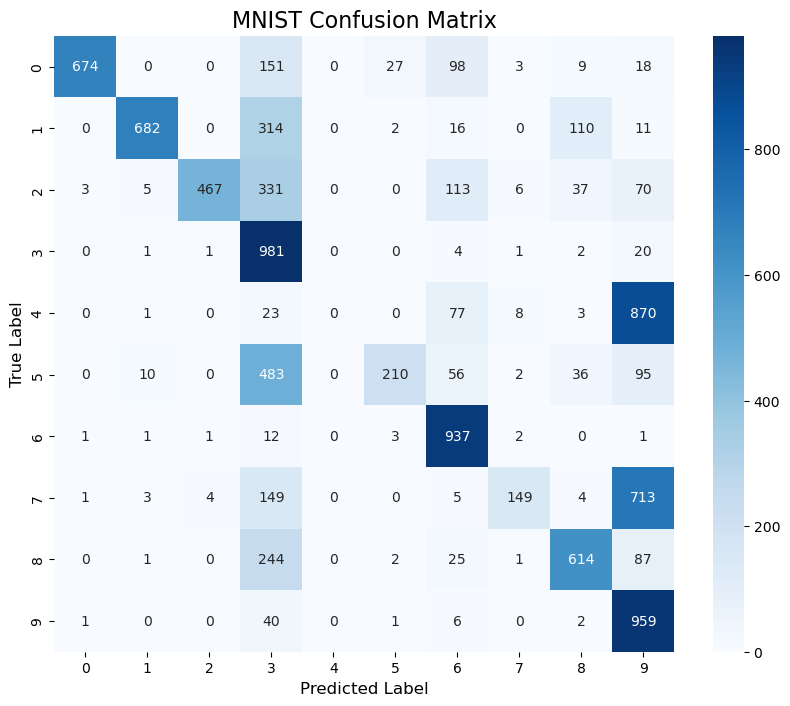

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (你前面计算 test_predictions 和 confusion_matrix 的代码保持不变) ...

# 设置画布大小
plt.figure(figsize=(10, 8))

# 绘制热力图
# annot=True 表示在方格内显示具体的数字
# fmt='d' 表示以整数形式显示
# cmap='Blues' 表示使用蓝色的渐变色系
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))

# 添加标题和坐标轴标签
plt.title('MNIST Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# 显示图像
plt.show()

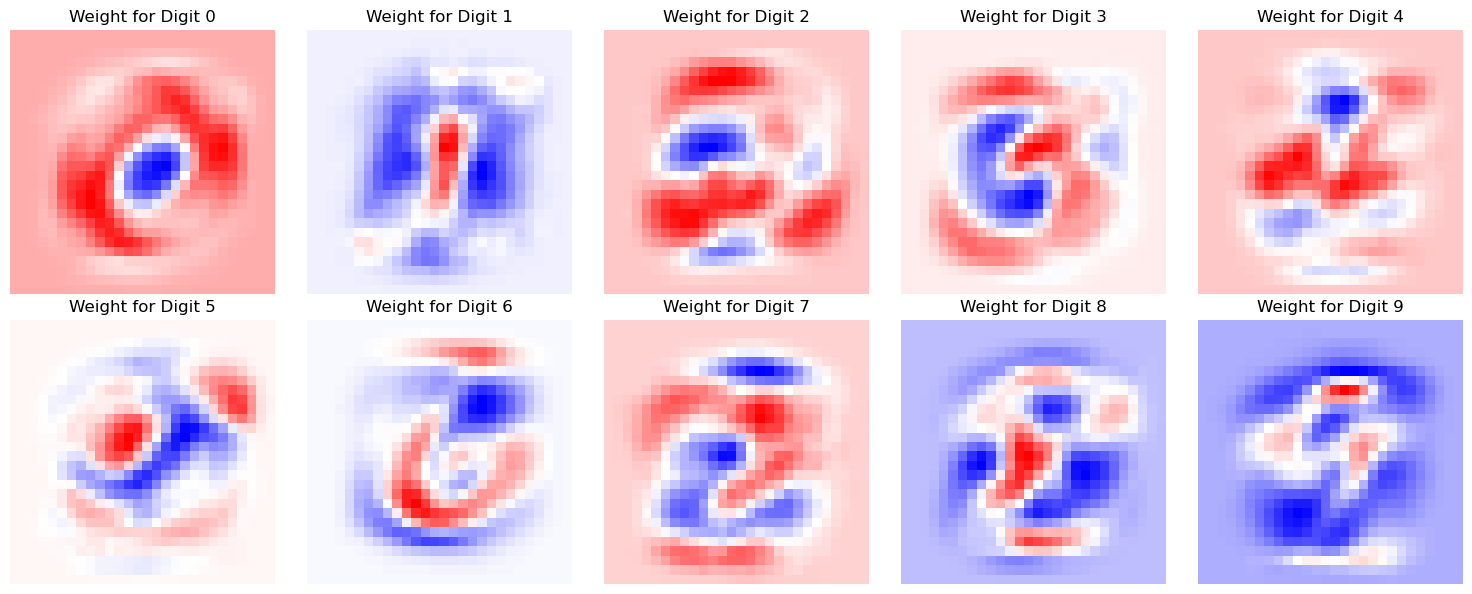

In [20]:
import matplotlib.pyplot as plt

# 创建 2 行 5 列的画布
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(10):
    ax = axes[i//5, i%5]
    
    # 提取第 i 列的前 784 个权重（去掉最后一个代表偏置的维度），并变回 28x28 矩阵
    weight_img = W[:-1, i].reshape(28, 28)
    
    # 画图：使用 'bwr' (蓝-白-红) 颜色映射
    # 红色代表正权重（加分项），蓝色代表负权重（扣分项），白色代表权重接近 0（不关心）
    im = ax.imshow(weight_img, cmap='bwr')
    ax.set_title(f'Weight for Digit {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()